In [1]:
import sys
print(sys.executable)

C:\Users\user\anaconda3\python.exe


## Step 1: Import Libraries

In [2]:
import os
import pandas as pd
import PyPDF2
import docx
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords

## Step 2: Setup

In [3]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

base_path = r"C:\Users\user\Resume_Classifier_App\Resumes"

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Step 3: Read Files (TEMP – using FilePath internally)

In [4]:
all_files = []

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(('.pdf', '.docx')):
            full_path = os.path.join(root, file)
            category = os.path.basename(root)
            all_files.append([file, full_path, category])

raw_df = pd.DataFrame(all_files, columns=["FileName", "FilePath", "Category"])

print("Total files:", raw_df.shape)
raw_df.head()

Total files: (79, 3)


,FileName,FilePath,Category
0,Internship_Ravali_Musquare Technologies (1).docx,C:\Users\user\Resume_Classifier_App\Resumes\Ge...,General
1,Internship_Susovan Bag_Musquare Technologies.docx,C:\Users\user\Resume_Classifier_App\Resumes\Ge...,General
2,React Developer_Deepakreddy.docx,C:\Users\user\Resume_Classifier_App\Resumes\Ge...,General
3,React Developer_Haripriya.docx,C:\Users\user\Resume_Classifier_App\Resumes\Ge...,General
4,React Developer_Kamalakar Reddy.docx,C:\Users\user\Resume_Classifier_App\Resumes\Ge...,General


## Step 4: Text Extraction Function

In [5]:
def extract_text(file_path):
    try:
        if file_path.endswith(".pdf"):
            text = ""
            with open(file_path, "rb") as f:
                reader = PyPDF2.PdfReader(f)
                for page in reader.pages:
                    text += page.extract_text() or ""
            return text

        elif file_path.endswith(".docx"):
            doc = docx.Document(file_path)
            return " ".join([p.text for p in doc.paragraphs])

        return ""
    except:
        return ""

## Step 5: Cleaning Function

In [6]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()
    words = [w for w in words if w not in stop_words]

    return " ".join(words)

## Step 6: Create RAW + CLEANED Dataset (IMPORTANT)

In [7]:
data_raw = []
data_clean = []

for i, row in raw_df.iterrows():
    text = extract_text(row['FilePath'])
    
    # RAW DATA
    raw_word_count = len(text.split())
    raw_length = len(text)   # 🔥 NEW (character length)
    
    data_raw.append([
        row['FileName'],
        text,
        row['Category'],
        raw_word_count,
        raw_length
    ])
    
    # CLEAN DATA
    clean_data = clean_text(text)
    clean_word_count = len(clean_data.split())
    
    if clean_data.strip() != "":
        data_clean.append([
            row['FileName'],
            clean_data,
            row['Category'],
            clean_word_count
        ])

## Step 7: Final DataFrames (YOUR FORMAT)

In [8]:
# RAW DATASET
raw_final_df = pd.DataFrame(
    data_raw,
    columns=[
        "File_Name",
        "Row_Data",
        "Category",
        "Word_Count",
        "Resume_Length"   # 🔥 NEW COLUMN
    ]
)

# CLEANED DATASET
cleaned_df = pd.DataFrame(
    data_clean,
    columns=["File_Name", "Cleaned_Resume", "Category", "Word_Count"]
)

# Remove weak data
cleaned_df = cleaned_df[cleaned_df['Word_Count'] > 10]

print("RAW:", raw_final_df.shape)
print("CLEANED:", cleaned_df.shape)

raw_final_df.head()

RAW: (79, 5)
CLEANED: (79, 4)


,File_Name,Row_Data,Category,Word_Count,Resume_Length
0,Internship_Ravali_Musquare Technologies (1).docx,Name: Ravali P ...,General,280,3498
1,Internship_Susovan Bag_Musquare Technologies.docx,SUSOVAN BAG Seeking a challenging po...,General,184,1667
2,React Developer_Deepakreddy.docx,Kanumuru Deepak Reddy CAREER OBJECTIVE: To...,General,501,3547
3,React Developer_Haripriya.docx,HARIPRIYA BATTINA Experience as UI Developer ...,General,406,2627
4,React Developer_Kamalakar Reddy.docx,KAMALAKAR REDDY. A Linked In: https://www.lin...,General,358,2621


In [9]:
cleaned_df.head()

,File_Name,Cleaned_Resume,Category,Word_Count
0,Internship_Ravali_Musquare Technologies (1).docx,name ravali p curriculum vitae specialization ...,General,215
1,Internship_Susovan Bag_Musquare Technologies.docx,susovan bag seeking challenging position field...,General,143
2,React Developer_Deepakreddy.docx,kanumuru deepak reddy career objective secure ...,General,350
3,React Developer_Haripriya.docx,haripriya battina experience ui developer reac...,General,252
4,React Developer_Kamalakar Reddy.docx,kamalakar reddy linked professional summary ye...,General,255


## Step 8: Save CSV Files

In [10]:
raw_final_df.to_csv("raw_resume_dataset.csv", index=False)
cleaned_df.to_csv("cleaned_resume_dataset.csv", index=False)

## Step 9: EDA (START)

## Category Distribution

In [11]:
category_counts = cleaned_df['Category'].value_counts()
print(category_counts)

Category
General                            24
workday resumes                    21
Peoplesoft resumes                 20
SQL Developer Lightning insight    14
Name: count, dtype: int64


## Bar Chart (Colored)

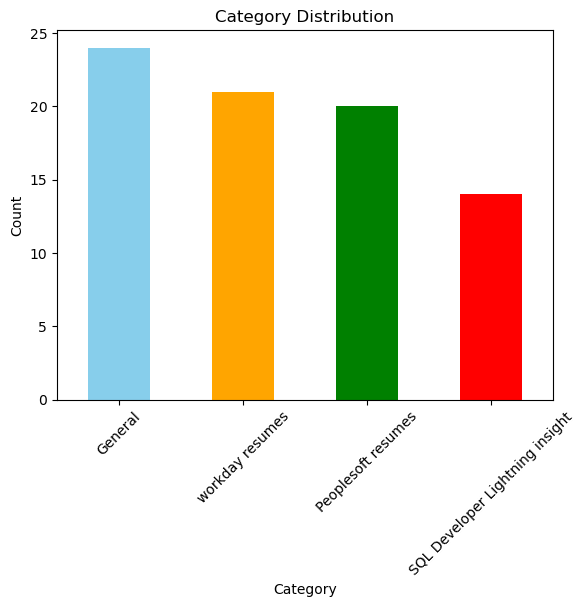

In [12]:
plt.figure()

category_counts.plot(
    kind='bar',
    color=['skyblue', 'orange', 'green', 'red']
)

plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

## Donut Pie Chart

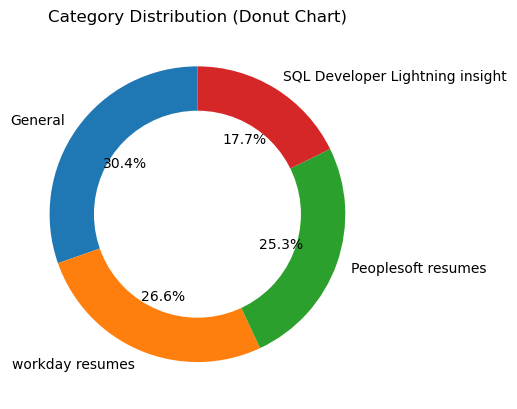

In [13]:
plt.figure()

plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

# Donut effect
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Category Distribution (Donut Chart)")
plt.show()

## Resume Length Analysis

In [14]:
cleaned_df['Resume_Length'] = cleaned_df['Cleaned_Resume'].apply(len)

cleaned_df['Resume_Length'].describe()

count       79.000000
mean      3678.443038
std       2535.957690
min        100.000000
25%       2000.000000
50%       3030.000000
75%       4817.000000
max      14231.000000
Name: Resume_Length, dtype: float64

## Histogram

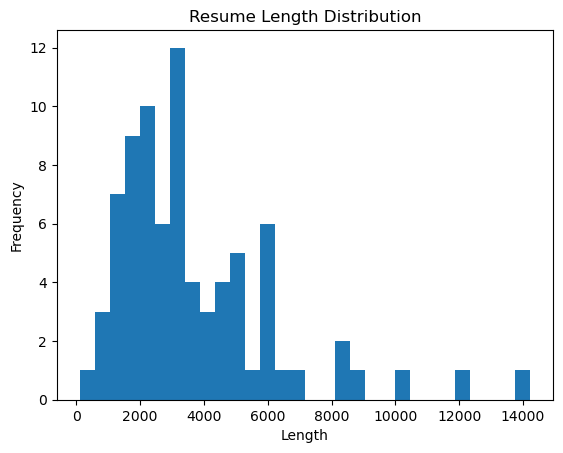

In [15]:
plt.figure()

plt.hist(cleaned_df['Resume_Length'], bins=30)

plt.title("Resume Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")

plt.show()

## Category-wise Boxplot

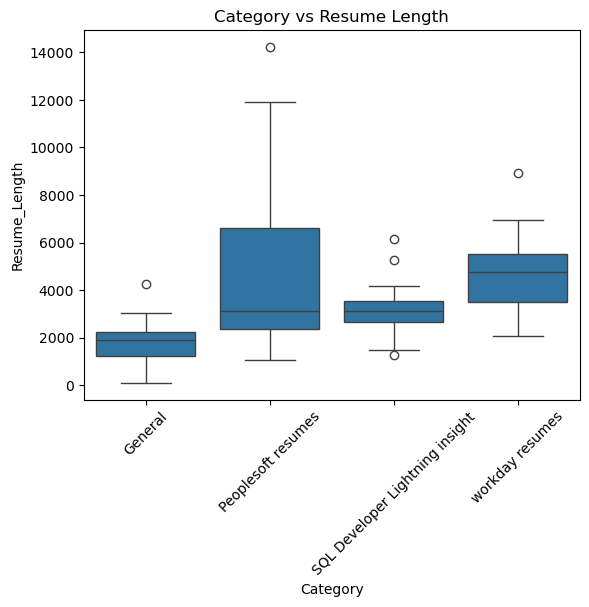

In [16]:
plt.figure()

sns.boxplot(
    x='Category',
    y='Resume_Length',
    data=cleaned_df
)

plt.xticks(rotation=45)
plt.title("Category vs Resume Length")

plt.show()

## Step 10: Feature Engineering (TF-IDF)

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.8
)

X = tfidf.fit_transform(cleaned_df['Cleaned_Resume'])
y = cleaned_df['Category']

print("Feature shape:", X.shape)

Feature shape: (79, 5000)


In [18]:
cleaned_df.to_csv("cleaned_resume_dataset.csv", index=False)

In [19]:
raw_final_df.head(10)

,File_Name,Row_Data,Category,Word_Count,Resume_Length
0,Internship_Ravali_Musquare Technologies (1).docx,Name: Ravali P ...,General,280,3498
1,Internship_Susovan Bag_Musquare Technologies.docx,SUSOVAN BAG Seeking a challenging po...,General,184,1667
2,React Developer_Deepakreddy.docx,Kanumuru Deepak Reddy CAREER OBJECTIVE: To...,General,501,3547
3,React Developer_Haripriya.docx,HARIPRIYA BATTINA Experience as UI Developer ...,General,406,2627
4,React Developer_Kamalakar Reddy.docx,KAMALAKAR REDDY. A Linked In: https://www.lin...,General,358,2621
5,React Developer_Naveen sadhu.docx,Naveen Sadhu Title: software developer\t\t\...,General,193,1450
6,React Developer_Pragnya.docx,PRAGNYA PATTNAIK Expertise: Having...,General,348,2609
7,React Developer_Sarala Madasu-converted.docx," 204,Sri geethika prestige,road number 10,b...",General,339,2542
8,React Developer_Thirupathiamma.docx,\n Thirupathamma Balla SUMMARY: 2.8 year of ...,General,133,994
9,React Dev_Krishna Kanth.docx,Ui-Developer/ React JS Developer NAME: KRISH...,General,521,3633


In [20]:
cleaned_df.head(10)

,File_Name,Cleaned_Resume,Category,Word_Count,Resume_Length
0,Internship_Ravali_Musquare Technologies (1).docx,name ravali p curriculum vitae specialization ...,General,215,1777
1,Internship_Susovan Bag_Musquare Technologies.docx,susovan bag seeking challenging position field...,General,143,1091
2,React Developer_Deepakreddy.docx,kanumuru deepak reddy career objective secure ...,General,350,2751
3,React Developer_Haripriya.docx,haripriya battina experience ui developer reac...,General,252,1954
4,React Developer_Kamalakar Reddy.docx,kamalakar reddy linked professional summary ye...,General,255,2080
5,React Developer_Naveen sadhu.docx,naveen sadhu title software developer location...,General,128,1062
6,React Developer_Pragnya.docx,pragnya pattnaik expertise around years experi...,General,246,1974
7,React Developer_Sarala Madasu-converted.docx,sri geethika prestige road number bandari layo...,General,258,2026
8,React Developer_Thirupathiamma.docx,thirupathamma balla summary year experience re...,General,97,814
9,React Dev_Krishna Kanth.docx,ui developer react js developer name krishna p...,General,415,3042


# MODEL BUILDING + MODEL EVALUATION

## Step 1: Load Cleaned Dataset

In [21]:
import pandas as pd

df = pd.read_csv("cleaned_resume_dataset.csv")

df.head()

,File_Name,Cleaned_Resume,Category,Word_Count,Resume_Length
0,Internship_Ravali_Musquare Technologies (1).docx,name ravali p curriculum vitae specialization ...,General,215,1777
1,Internship_Susovan Bag_Musquare Technologies.docx,susovan bag seeking challenging position field...,General,143,1091
2,React Developer_Deepakreddy.docx,kanumuru deepak reddy career objective secure ...,General,350,2751
3,React Developer_Haripriya.docx,haripriya battina experience ui developer reac...,General,252,1954
4,React Developer_Kamalakar Reddy.docx,kamalakar reddy linked professional summary ye...,General,255,2080


## Step 2: Define Features & Target

In [22]:
X_text = df['Cleaned_Resume']
y = df['Category']

## Step 3: TF-IDF Feature Engineering

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.8
)

X = tfidf.fit_transform(X_text)

## Step 4: Train-Test Split

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (63, 5000)
Test Shape: (16, 5000)


## Step 5: Model Building (Multiple Models)

### 5.1 Logistic Regression

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 1.0


### 5.2 Naive Bayes

In [26]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 1.0


### 5.3 Support Vector Machine (SVM)

In [27]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 1.0


### 5.4 Random Forest

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 1.0


## Step 6: Model Comparison

In [29]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Naive Bayes": accuracy_score(y_test, y_pred_nb),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "Random Forest": accuracy_score(y_test, y_pred_rf)
}

results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])

print(results_df)

                 Model  Accuracy
0  Logistic Regression       1.0
1          Naive Bayes       1.0
2                  SVM       1.0
3        Random Forest       1.0


## Step 7: Visualization (Model Comparison)

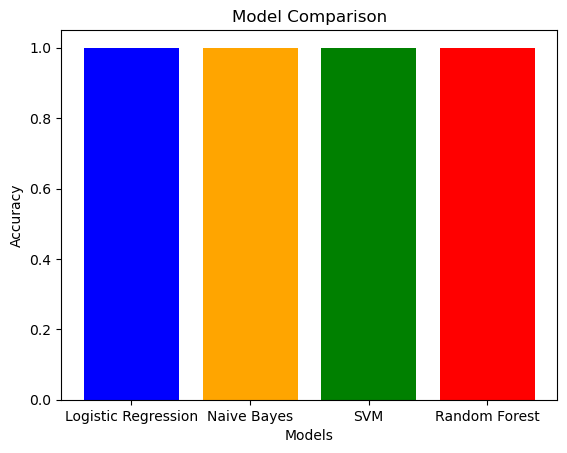

In [30]:
#import matplotlib.pyplot as plt

plt.figure()

plt.bar(
    results_df['Model'],
    results_df['Accuracy'],
    color=['blue', 'orange', 'green', 'red']
)

plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

## Step 8: Select Best Model

In [31]:
best_model = results_df.loc[results_df['Accuracy'].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Model       Logistic Regression
Accuracy                    1.0
Name: 0, dtype: object


## Step 9: Cross Validation (VERY IMPORTANT)

In [32]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(lr, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average CV Accuracy:", scores.mean())

Cross Validation Scores: [0.9375     0.9375     1.         1.         0.93333333]
Average CV Accuracy: 0.9616666666666667


## Step 10: Final Model Evaluation (Logistic Regression)

### 10.1 Final Prediction

In [33]:
y_pred_final = lr.predict(X_test)

### 10.2 Confusion Matrix

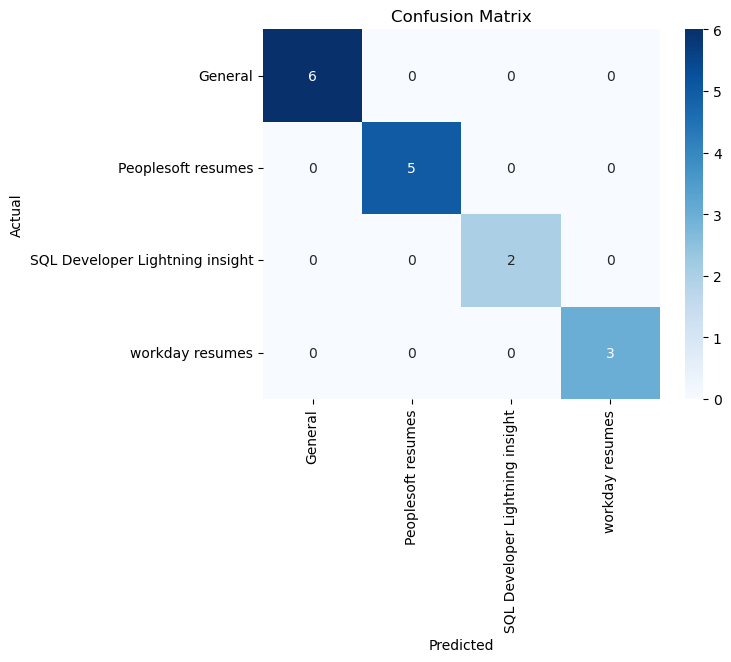

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_final)

plt.figure()

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=lr.classes_,
    yticklabels=lr.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### 10.3 Classification Report

In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_final))

                                 precision    recall  f1-score   support

                        General       1.00      1.00      1.00         6
             Peoplesoft resumes       1.00      1.00      1.00         5
SQL Developer Lightning insight       1.00      1.00      1.00         2
                workday resumes       1.00      1.00      1.00         3

                       accuracy                           1.00        16
                      macro avg       1.00      1.00      1.00        16
                   weighted avg       1.00      1.00      1.00        16



### 10.4 Overfitting Check

In [36]:
print("Train Accuracy:", lr.score(X_train, y_train))
print("Test Accuracy:", lr.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 1.0


## Step 11: Save Final Model

In [37]:
import pickle

pickle.dump(lr, open("final_model.pkl", "wb"))
pickle.dump(tfidf, open("tfidf.pkl", "wb"))

# DEPLOYMENT USING STREAMLIT

## Step 1: Install Required Libraries

In [39]:
!pip install streamlit

ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\user\anaconda3\Lib\site-packages\pip\_internal\cli\base_command.py", line 160, in exc_logging_wrapper
    status = run_func(*args)
  File "C:\Users\user\anaconda3\Lib\site-packages\pip\_internal\cli\req_command.py", line 247, in wrapper
    return func(self, options, args)
  File "C:\Users\user\anaconda3\Lib\site-packages\pip\_internal\commands\install.py", line 341, in run
    session = self.get_default_session(options)
  File "C:\Users\user\anaconda3\Lib\site-packages\pip\_internal\cli\req_command.py", line 98, in get_default_session
    self._session = self.enter_context(self._build_session(options))
                                       ~~~~~~~~~~~~~~~~~~~^^^^^^^^^
  File "C:\Users\user\anaconda3\Lib\site-packages\pip\_internal\cli\req_command.py", line 125, in _build_session
    session = PipSession(
        cache=os.path.join(cache_dir, "http") if cache_dir else None,
    ...<3 lines>...
        ssl_context=ss